In [1]:
#import data
import pandas as pd
data1 = pd.read_excel("C:/Users\luenx/OneDrive\Desktop/UMP/UMP/Sem 6/group project/final ridership.xlsx", header = 0, index_col = 0, sheet_name='Sheet1')
data1

,Gombak,Tmn Melati,Wangsa Maju,Sri Rampai,Setiawangsa,Jelatek,Dato Keramat,Damai,Ampang Park,KLCC,...,Subang Alam,Putra Heights,Failure RS,Failure TNM,Failure POW,Failure SIG,Total Failure,Relevant Failure,Service Downtime,Total Ridership
Date,,,,,,,,,,,,,,,,,,,,,
2019-01,149681,181641,342489,152937,160329,82738,58416,78263,373900,878511,...,19001,113461,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7900483
2019-02,134832,150028,259205,128786,134842,72096,50772,66569,288153,746442,...,16258,95552,0.0,0.0,0.0,2.0,2.0,2.0,101.3,6523515
2019-03,163773,187521,361187,154887,165211,84353,59804,80645,372452,881367,...,19070,121500,0.0,0.0,0.0,1.0,1.0,1.0,8.2,8127743
2019-04,160772,188687,349884,152847,164085,83443,59324,78404,387323,886256,...,19384,127466,2.0,0.0,0.0,0.0,2.0,2.0,17.0,8189219
2019-05,151824,177009,324622,146806,152998,80497,61126,79560,355028,818289,...,18452,121373,1.0,0.0,2.0,0.0,1.0,1.0,27.9,7746135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12,115137,170177,256759,122923,114045,89057,42341,62618,358976,702826,...,14721,109687,193.0,6.0,7.0,24.0,230.0,1.0,49.0,6479670
2024-01,113681,160963,244705,130006,120383,91158,42602,61983,359943,613451,...,15657,122049,218.0,6.0,5.0,13.0,242.0,2.0,59.0,6591331
2024-02,102891,144380,214270,120386,115045,87625,37821,57428,322496,642517,...,15375,111636,172.0,5.0,4.0,19.0,200.0,0.0,65.0,6236607


In [2]:
#filter 'Ara Damansara' tod site
# List of column names to keep
columns_to_keep = ['Ara Damansara']

# Filter columns
filtered_df = data1[columns_to_keep]

# Display the filtered DataFrame
print(filtered_df)


         Ara Damansara
Date                  
2019-01         120821
2019-02          98165
2019-03         125921
2019-04         128168
2019-05         121971
...                ...
2023-12         114282
2024-01         130402
2024-02         117961
2024-03         136031
2024-04         123409

[64 rows x 1 columns]


In [3]:
#checking null value 
filtered_df.isnull().sum()

Ara Damansara    0
dtype: int64

In [4]:
#checking duplicated data
duplicated_rows = filtered_df[filtered_df.duplicated()]
duplicated_rows

,Ara Damansara
Date,


In [5]:
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 64 entries, 2019-01 to 2024-04
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Ara Damansara  64 non-null     int64
dtypes: int64(1)
memory usage: 3.5 KB


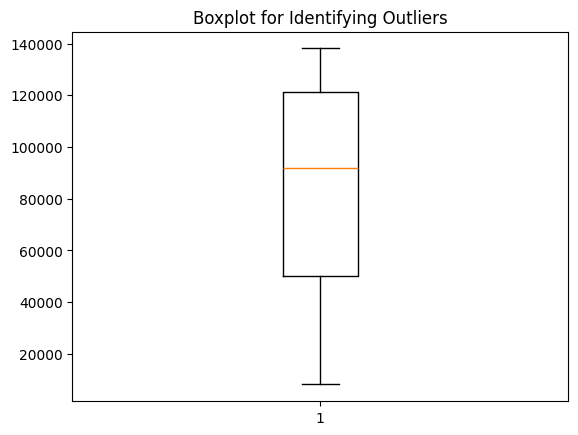

In [6]:
#checking for outliers
import matplotlib.pyplot as plt

# Create a boxplot
plt.boxplot(filtered_df['Ara Damansara'])
plt.title('Boxplot for Identifying Outliers')
plt.show()

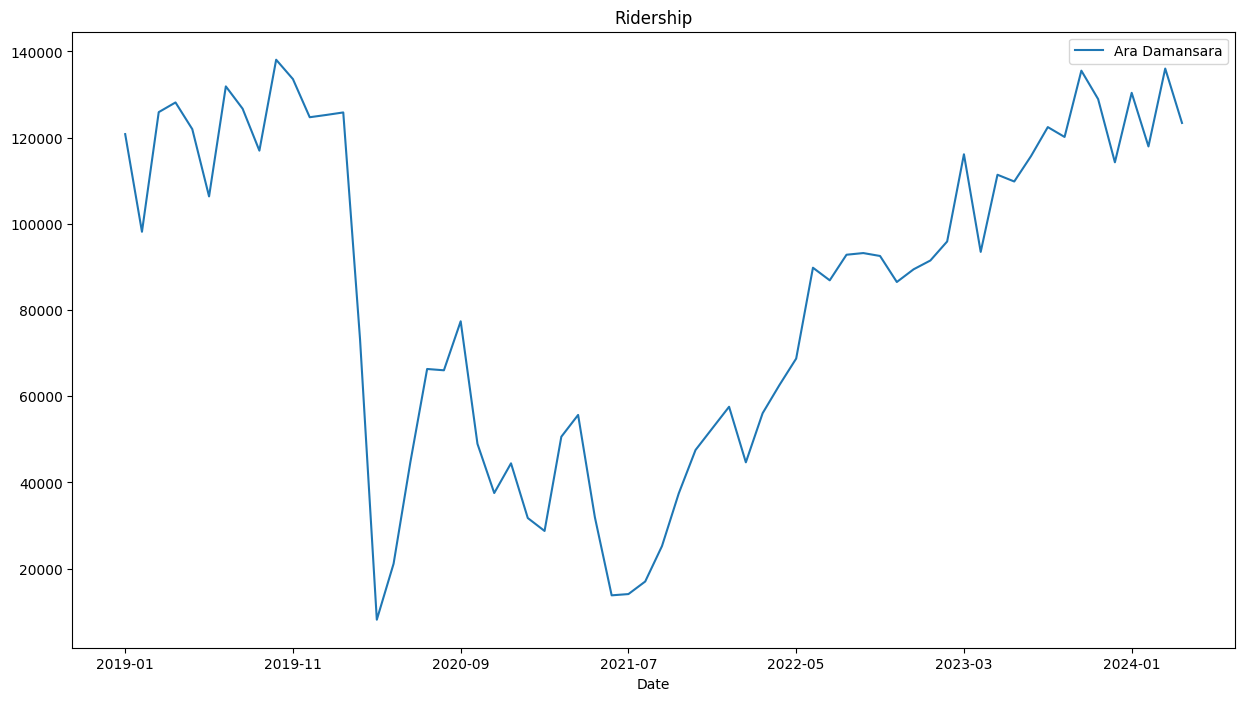

In [7]:
#plot the time series data
from matplotlib import pyplot
filtered_df.plot(figsize = (15, 8), title='Ridership', fontsize=10)
pyplot.show()

In [8]:
#Split data training (in-sample) & testing (out-sample)
training = filtered_df[0:48] # 48 in-sample data
testing = filtered_df[48:] #16 out-sample data

In [9]:
training.head(5) #display training data

,Ara Damansara
Date,
2019-01,120821
2019-02,98165
2019-03,125921
2019-04,128168
2019-05,121971


In [10]:
testing.head() #display testing data

,Ara Damansara
Date,
2023-01,91498
2023-02,95911
2023-03,116147
2023-04,93489
2023-05,111392


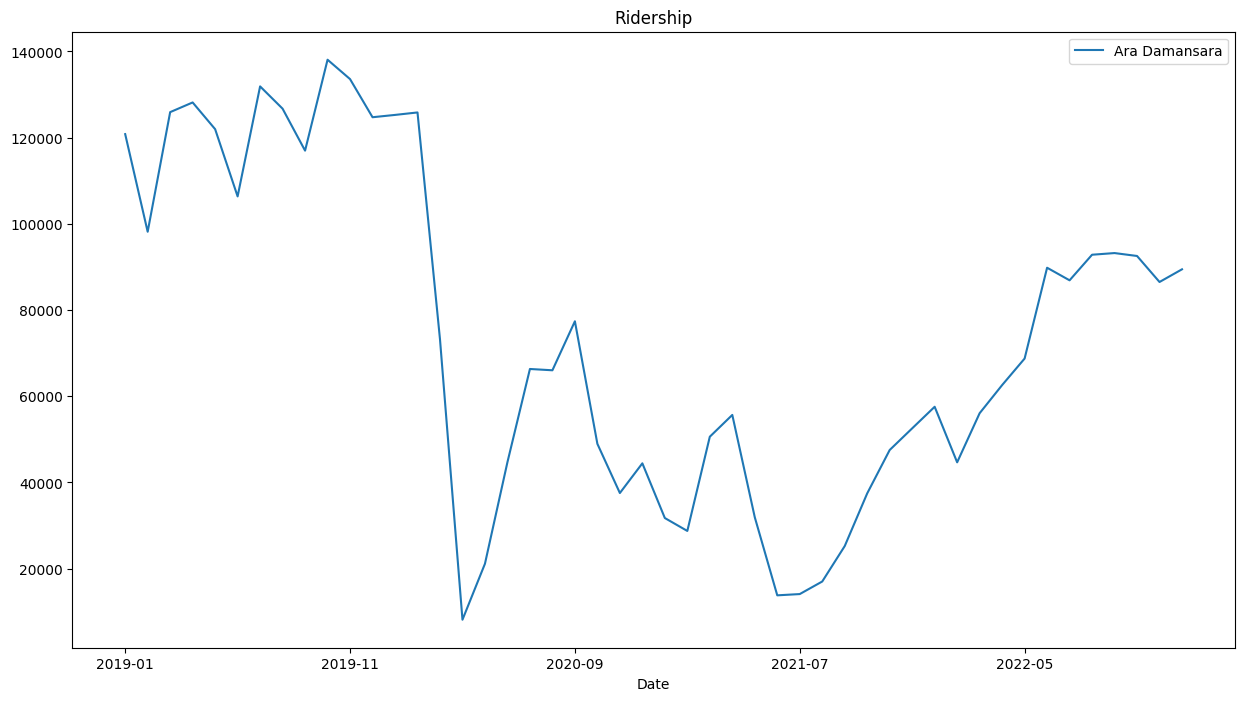

In [11]:
#plot the training data
from matplotlib import pyplot
training.plot(figsize = (15, 8), title='Ridership', fontsize=10)
pyplot.show()

In [12]:
training.describe()

,Ara Damansara
count,48.000000
mean,73743.395833
std,39016.192266
min,8146.000000
25%,44608.250000
50%,67533.500000
75%,109021.250000
max,138082.000000


In [13]:
#normality for in-sample data
from scipy.stats import shapiro 
shapiro(training)

ShapiroResult(statistic=np.float64(0.940143149446841), pvalue=np.float64(0.016435851619513806))

$H_0$: The time series is normally distributed\
$H_1$: The time series is not normally distributed\
\
$p-value=0.0062$\
Since $(p-value=0.0062)<(\alpha=0.05)$, reject $H_0$.\
\
At $\alpha=0.05$, the time series is not normally distributed.



For Skewness,

a) If the coefficient of skewness is greater than 0, then the graph is said to be positively skewed with the majority of data values less than mean. Most of the values are concentrated on the left side of the graph.

b) If the coefficient of skewness is equal to 0 or approximately close to 0, then the graph is said to be symmetric and data is normally distributed.

c) If the coefficient of skewness is less than 0, then the graph is said to be negatively skewed with the majority of data values greater than mean. Most of the values are concentrated on the right side of the graph

In [14]:
#skewness in-sample data
from scipy.stats import skew
skew(training)

array([0.10392516])

Coefficient of skewness is less than 0, then the graph is said to be negatively skewed with the majority of data values greater than mean. Most of the values are concentrated on the right side of the graph.

array([[<Axes: title={'center': 'Ara Damansara'}>]], dtype=object)

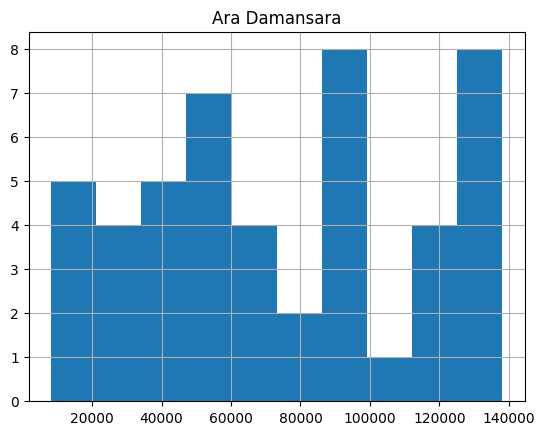

In [15]:
#histogram in-sample data
training.hist()

Kurtosis is a numerical method in statistics that measures the sharpness of the peak in the data distribution.\
There exist 3 types of Kurtosis values on the basis of which sharpness of the peak is measured. These are as follows:
 

a) Platykurtic\
If a given distribution has a kurtosis less than 3, it is said to be platykurtic, which means it tends to produce fewer and less extreme outliers than the normal distribution.

b) Mesokurtic\
If the coefficient of kurtosis is equal to 3 or approximately close to 3, then the data distribution is mesokurtic. For normal distribution, kurtosis value is approximately equal to 3.

c) Leptokurtic\
If the coefficient of kurtosis is greater than 3, then the data distribution is leptokurtic and shows a sharp peak on the graph.or If a given distribution has a kurtosis greater than 3, it is said to be leptokurtic, which means it tends to produce more outliers than the normal distribution.


https://www.geeksforgeeks.org/skewness-and-kurtosis-in-r-programming/
https://www.statology.org/skewness-kurtosis-python/

In [16]:
#kurtosis in-sample data
from scipy.stats import kurtosis
kurtosis(training)

array([-1.24000844])

it is said to be platykurtic, which means it tends to produce fewer and less extreme outliers than the normal distribution.

Stage 1: Model Identification
    
Part Three: Data stationarity
    
a) Stationarity in-variance : Use Box-Cox transformation to check the stationarity in-variance

In [17]:
#Box-cox transformation (check stationarity in variance)
Ridership = training['Ara Damansara']
import scipy as sp
from scipy.stats import boxcox
Ridership, lam = boxcox(Ridership)
lam

np.float64(0.6598297156125582)

Running the transformation discovers the $\lambda=0.6598$. We can see that this is greater than $\lambda=0.5$ and close to $\lambda=1$. Hence, no transformation is needed. It is confirmed that the data is stationary in-variance.

a) Stationarity in-mean : Use ADF test and ACF & PACF plot to check the stationarity in-mean

In [18]:
#stationary test using ADF test (to check stationarity in mean)
from statsmodels.tsa.stattools import adfuller
print("p-value:", adfuller(training.dropna())[1])

p-value: 0.3233285506702013


$H_0$: The time series is non-stationary\
$H_1$: The time series is stationary\
\
$p-value=0.3233$\
\
Since $p-value=0.3233>\alpha=0.05$ do not reject $H_0$.\
\
At $\alpha=0.05$, the time series is not stationary in-mean.

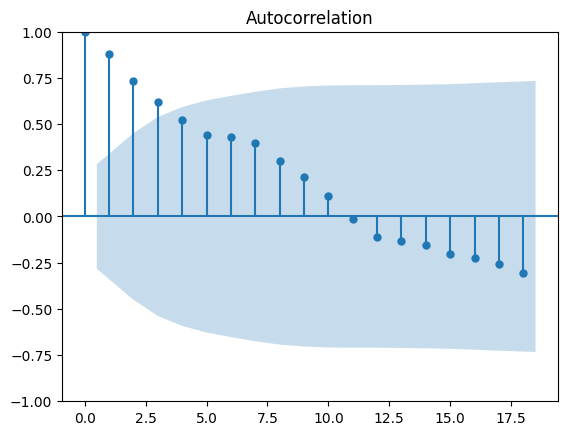

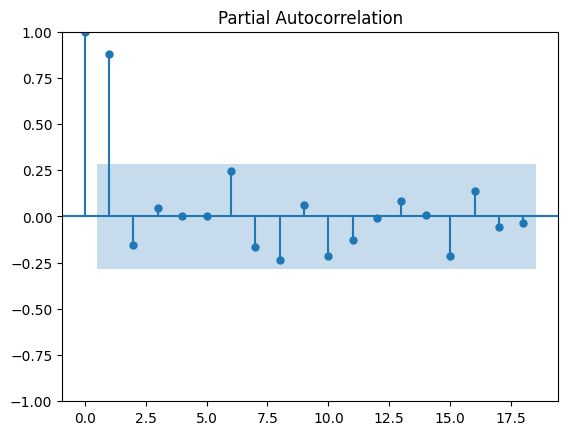

In [19]:
#stationarity test in mean using ACF & PACF plot 
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
plot_acf(training,lags = 18),plot_pacf(training, lags = 18) #determine lag using kmax=10*log (10)T=21
plt.show()

ACF plot shows that the value of autocorrelation coefficient is large and the ACF plot / ACF value decreases slowly, means that the data is not stationary in-mean.

Need to do differencing because the data is not stationary in-mean.

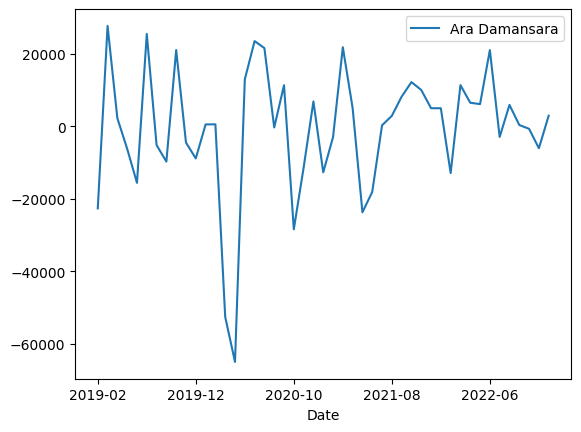

In [20]:
#first differencing
diff_1 = training.diff(1).dropna()
from matplotlib import pyplot
diff_1.plot()
pyplot.show()

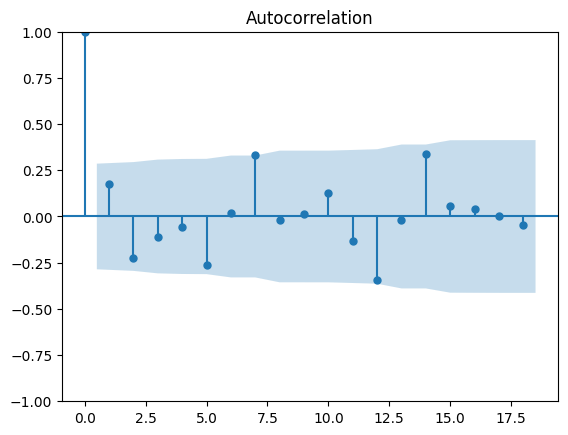

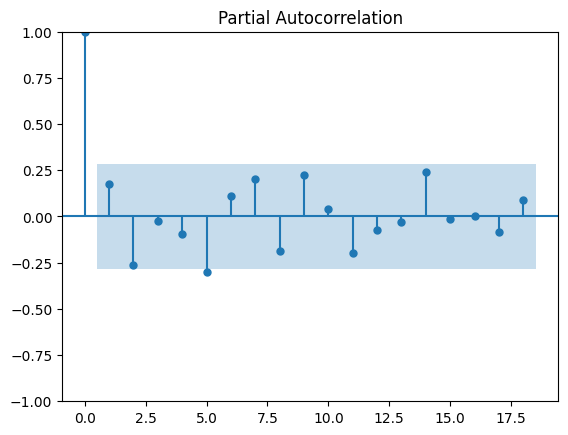

In [21]:
#plot ACF & PACF after first differencing
plot_acf(diff_1, lags=18),plot_pacf(diff_1,lags=18)
plt.show()

Stage 1 : Model Identification

Part Four : Data serially correlated

In [22]:
#serial correlation
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(training, lags=[18], return_df=True)

,lb_stat,lb_pvalue
18,165.5937,6.666569e-26


$H_0$: The time series is not serial correlated\
$H_1$: The time series is serial correlated\
\
$p-value=0.0000$\
\
Since $p-value=0.0000<\alpha=0.05$ reject $H_0$.\
\
At $\alpha=0.05$, there exist serial correlation between the data series.

1) The appropriate model are : ARIMA (since the data is stationary in-variance and not-stationary in-mean and differencing has been done to make it stationary. )
2) The possible model:

ACF plot : q=1

PACF plot : p=1

d=1

ARIMA(1,1,1)

# Model Summary

In [23]:
import statsmodels.api as sm
model2 = sm.tsa.ARIMA(training, order=(1, 1, 1)) # t means that the model with intercept
# Fit the model
results = model2.fit()

C:\Users\luenx\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\luenx\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\luenx\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [24]:
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:          Ara Damansara   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -526.817
Date:                Mon, 09 Mar 2026   AIC                           1059.635
Time:                        15:48:19   BIC                           1065.185
Sample:                    01-01-2019   HQIC                          1061.724
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9566      0.125     -7.679      0.000      -1.201      -0.712
ma.L1          0.9366      0.158      5.930      0.000       0.627       1.246
sigma2      2.922e+08    4.5e-10   6.49e+17      0.0

# Diagnostic Checking

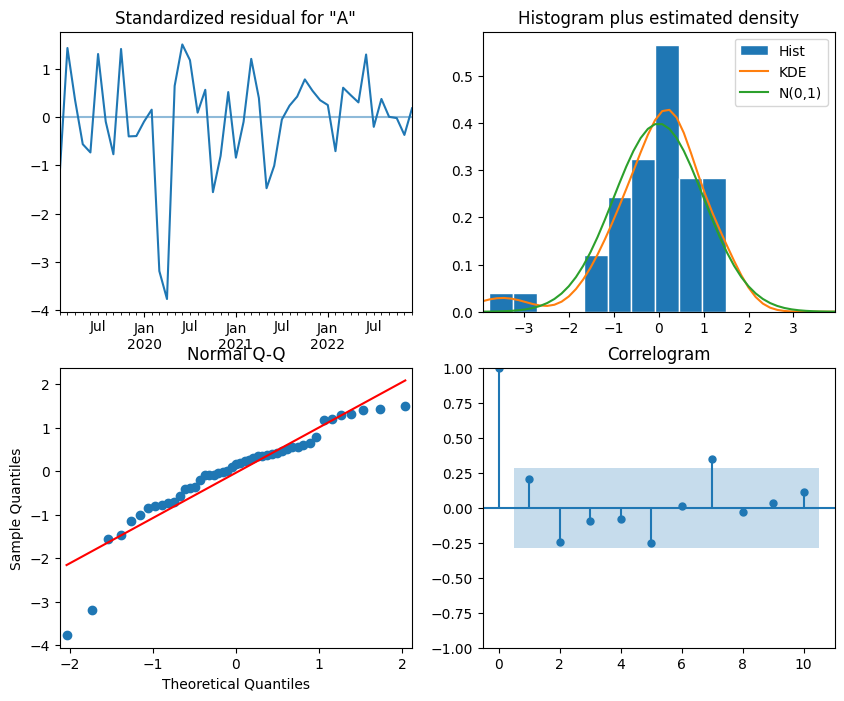

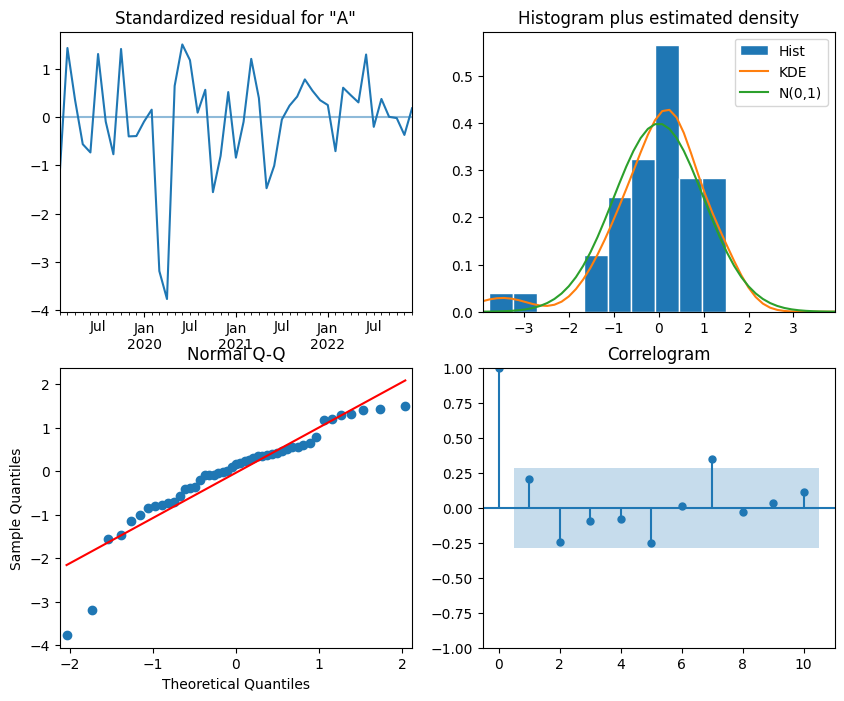

In [25]:
# visualise the diagnostic checking
results.plot_diagnostics(figsize=(10,8))

In [26]:
residuals = pd.DataFrame(results.resid)
residuals # get from the actual training data with the fitted training data

,0
Date,
2019-01,120821.000000
2019-02,-19708.551153
2019-03,24464.915622
2019-04,5968.689440
2019-05,-9619.952022
2019-06,-12548.291022
2019-07,22323.793174
2019-08,-1616.810309
2019-09,-13171.159649


# Serial Correlation

In [27]:
# test serial correlation on residuals (residuals must be not correlated)
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(residuals, lags=[18])

,lb_stat,lb_pvalue
18,14.174513,0.717646


$H_0$: The residuals is not serial correlated\
$H_1$: The residuals is serial correlated\
\
$p-value=0.7176$\
\
Since $p-value=0.7176>\alpha=0.05$, do not reject $H_0$.\
\
At $\alpha=0.05$, residuals is not serial correlated.

# Homoscedasticity test

In [28]:
# Ljung-Box test on squared residuals (homoscedasticity test : constant in variance).
import numpy as np
homoscedasticity = np.square(residuals)
acorr_ljungbox(homoscedasticity, lags=[18], return_df=True)

,lb_stat,lb_pvalue
18,6.3431,0.994595


$H_0$: No ARCH effect in the residuals (error variance is constant)\
$H_1$: There exist ARCH effect on residuals\
\
$p-value=0.9946$\
\
Since $p-value=0.9946 > \alpha=0.05$ do not reject $H_0$.\
\
At $\alpha=0.05$, no ARCH effect on the residuals.\
\
Homoscedasticity is a condition where the error variance is constanct on the independent variable

# Normality Test

In [29]:
# Normality test using Jarque-Bera test
import scipy.stats as stats
stats.jarque_bera(residuals)

SignificanceResult(statistic=np.float64(220.5035743273218), pvalue=np.float64(1.312977291510335e-48))

$H_0$: The residuals follows normal distributions\
$H_1$: The residuals do not follows normal distributions\
\
$p-value=0.0000$\
\
Since $p-value=0.0000<\alpha=0.05$, reject $H_0$.\
\
At $\alpha=0.05$, the residuals do not follow normal distributions.


# Forecasting

predictions = [] # forecasted testing data

# Make predictions
for i in range(len(testing)):
    yhat = results.forecast(steps=1)  # One-step ahead forecast
    predictions.append(yhat[0])  # Store forecast
    training = training.append(testing.iloc[[i]])  # Append actual value to training data
    
    # Retrain model on updated training data
    model2 = sm.tsa.ARIMA(training, order=(1, 1, 1))
    results = model2.fit()

# Convert predictions to DataFrame
testing_forecasted = pd.DataFrame(predictions, columns=['forecast'])

# Combine actual and forecasted data for plotting
result = pd.concat([testing.reset_index(), testing_forecasted], axis=1).set_index('Date')

# Plot comparison actual out-sample with forecasted out-sample
result[['Ara Damansara', 'forecast']].plot(figsize=(15, 8), title = 'Ridership', fontsize = 10)
plt.show()


from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

mape = mean_absolute_percentage_error(testing['Ara Damansara'], testing_forecasted['forecast'])
rmse = np.sqrt(mean_squared_error(testing['Ara Damansara'], testing_forecasted['forecast']))
mae = mean_absolute_error(testing['Ara Damansara'], testing_forecasted['forecast'])

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


In [30]:
# initialize variables for storing predictions and actual values
predictions = [] # forecasted testing data
actuals = [] # actual testing data

# iterate over each time step in the testing data
for i in range(len(testing)):
    # make one-step ahead forecast
    yhat = results.forecast()
    
    # store prediction and actual value
    predictions.append(yhat)
    actuals.append(testing.iloc[i])
    
    # add actual value to training data
    training = pd.concat([training, pd.DataFrame([testing.iloc[i]], columns=training.columns)], ignore_index=True)
    
    # retrain model on updated training data
    model2 = sm.tsa.ARIMA(training, order=(1, 1, 1))
    results = model2.fit()

    # last_actual_value = testing.iloc[-1]

C:\Users\luenx\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
predictions

[2023-01-01    89537.236611
 Freq: MS, dtype: float64,
 49    91344.476073
 dtype: float64,
 50    95909.367364
 dtype: float64,
 51    115439.946185
 dtype: float64,
 52    95547.588097
 dtype: float64,
 53    108999.96857
 dtype: float64,
 54    112206.14441
 dtype: float64,
 55    113264.227671
 dtype: float64,
 56    124685.734336
 dtype: float64,
 57    117979.131163
 dtype: float64,
 58    135252.942437
 dtype: float64,
 59    129508.619151
 dtype: float64,
 60    115982.754927
 dtype: float64,
 61    128229.872626
 dtype: float64,
 62    120324.757681
 dtype: float64,
 63    133435.350703
 dtype: float64]

In [32]:
import numpy as np
a=np.array(predictions) #convert forecasted testing data into array
testing_forecasted=pd.DataFrame(a, columns=['forecast']) #convert into Dataframe

In [33]:
testing_forecasted

,forecast
0,89537.236611
1,91344.476073
2,95909.367364
3,115439.946185
4,95547.588097
5,108999.968570
6,112206.144410
7,113264.227671
8,124685.734336
9,117979.131163


In [34]:
testing=testing.reset_index()#reset index testing data
testing

,Date,Ara Damansara
0,2023-01,91498
1,2023-02,95911
2,2023-03,116147
3,2023-04,93489
4,2023-05,111392
5,2023-06,109828
6,2023-07,115721
7,2023-08,122451
8,2023-09,120161
9,2023-10,135541


In [35]:
frames=[testing, testing_forecasted]#combine actual and forecast testing data
frames

[       Date  Ara Damansara
 0   2023-01          91498
 1   2023-02          95911
 2   2023-03         116147
 3   2023-04          93489
 4   2023-05         111392
 5   2023-06         109828
 6   2023-07         115721
 7   2023-08         122451
 8   2023-09         120161
 9   2023-10         135541
 10  2023-11         128946
 11  2023-12         114282
 12  2024-01         130402
 13  2024-02         117961
 14  2024-03         136031
 15  2024-04         123409,
          forecast
 0    89537.236611
 1    91344.476073
 2    95909.367364
 3   115439.946185
 4    95547.588097
 5   108999.968570
 6   112206.144410
 7   113264.227671
 8   124685.734336
 9   117979.131163
 10  135252.942437
 11  129508.619151
 12  115982.754927
 13  128229.872626
 14  120324.757681
 15  133435.350703]

In [36]:
result = pd.concat(frames, axis=1)
result

,Date,Ara Damansara,forecast
0,2023-01,91498,89537.236611
1,2023-02,95911,91344.476073
2,2023-03,116147,95909.367364
3,2023-04,93489,115439.946185
4,2023-05,111392,95547.588097
5,2023-06,109828,108999.968570
6,2023-07,115721,112206.144410
7,2023-08,122451,113264.227671
8,2023-09,120161,124685.734336
9,2023-10,135541,117979.131163


In [37]:
result= result.set_index('Date')
result

,Ara Damansara,forecast
Date,,
2023-01,91498,89537.236611
2023-02,95911,91344.476073
2023-03,116147,95909.367364
2023-04,93489,115439.946185
2023-05,111392,95547.588097
2023-06,109828,108999.968570
2023-07,115721,112206.144410
2023-08,122451,113264.227671
2023-09,120161,124685.734336


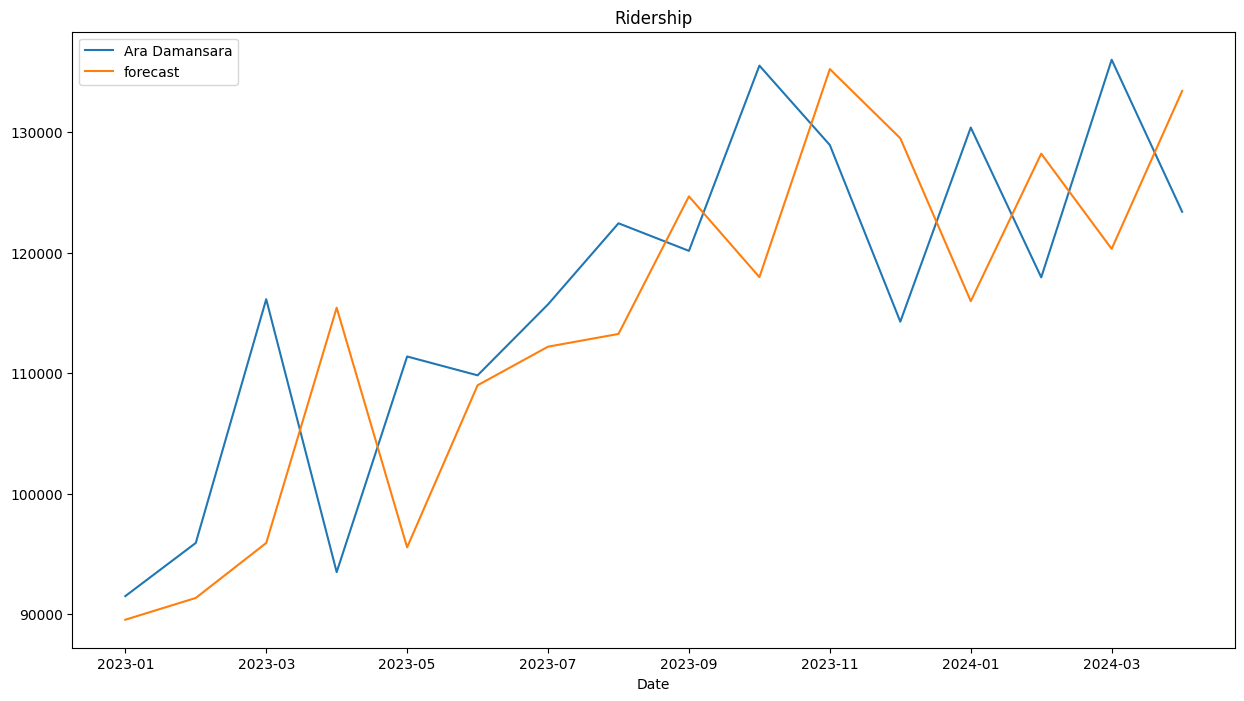

In [38]:
#plot comparison actual out-sample with forecasted out-sample
import matplotlib.pyplot as plt
result.plot(figsize=(15, 8),title = 'Ridership', fontsize = 10)
plt.show()


In [39]:
from sklearn.metrics import mean_absolute_percentage_error
#forecast evaluation using : MAPE
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) *100
mean_absolute_percentage_error(testing['Ara Damansara'], testing_forecasted['forecast'])

np.float64(9.231028278069147)

In [40]:
#forecast evaluation using : RMSE
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(testing['Ara Damansara'], testing_forecasted['forecast']))

np.float64(12564.044950749822)

In [41]:
#forecast evaluation using : MAE
from sklearn.metrics import mean_absolute_error
mean_absolute_error(testing['Ara Damansara'],  testing_forecasted['forecast'])

10758.175804331851

# Generate forecasts for the next n_periods points beyond the end of the testing set



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assuming `training` is your training dataset and is up-to-date
# Ensure the ARIMA model is fitted to the latest training data
model2 = sm.tsa.ARIMA(training, order=(1, 1, 1))
results = model2.fit()

In [43]:
n_periods = 20
forecasts1=results.forecast(steps=n_periods)
forecasts1

64    126169.521780
65    123411.091361
66    126167.432003
67    123413.179555
68    126165.345391
69    123415.264586
70    126163.261940
71    123417.346458
72    126161.181645
73    123419.425178
74    126159.104500
75    123421.500749
76    126157.030502
77    123423.573176
78    126154.959644
79    123425.642464
80    126152.891924
81    123427.708619
82    126150.827335
83    123429.771643
Name: predicted_mean, dtype: float64

In [44]:
import numpy as np
c=np.array(forecasts1) #convert forecasted testing data into array
#a=np.asarray(a, dtype = 'int') #convert into integer
future_forecast1=pd.DataFrame(c, columns=['forecast']) #convert into Dataframe
future_forecast1

,forecast
0,126169.521780
1,123411.091361
2,126167.432003
3,123413.179555
4,126165.345391
5,123415.264586
6,126163.261940
7,123417.346458
8,126161.181645
9,123419.425178


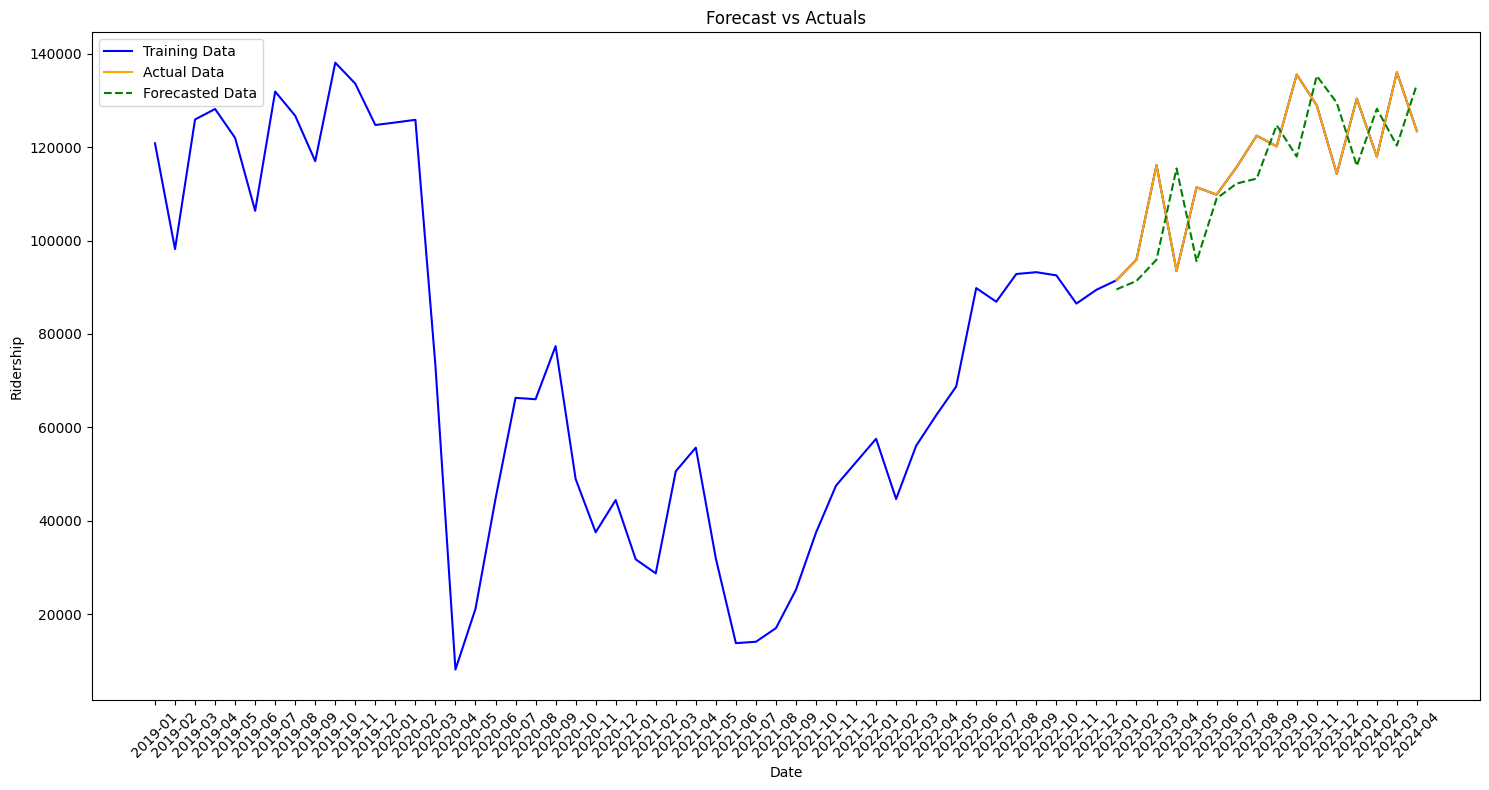

In [45]:
plt.figure(figsize=(15, 8))
plt.plot(filtered_df.index, filtered_df['Ara Damansara'], label='Training Data', color='blue')
plt.plot(result.index, result['Ara Damansara'], label='Actual Data', color='orange')
plt.plot(result.index, result['forecast'], label='Forecasted Data', color='green', linestyle='--')

plt.title('Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

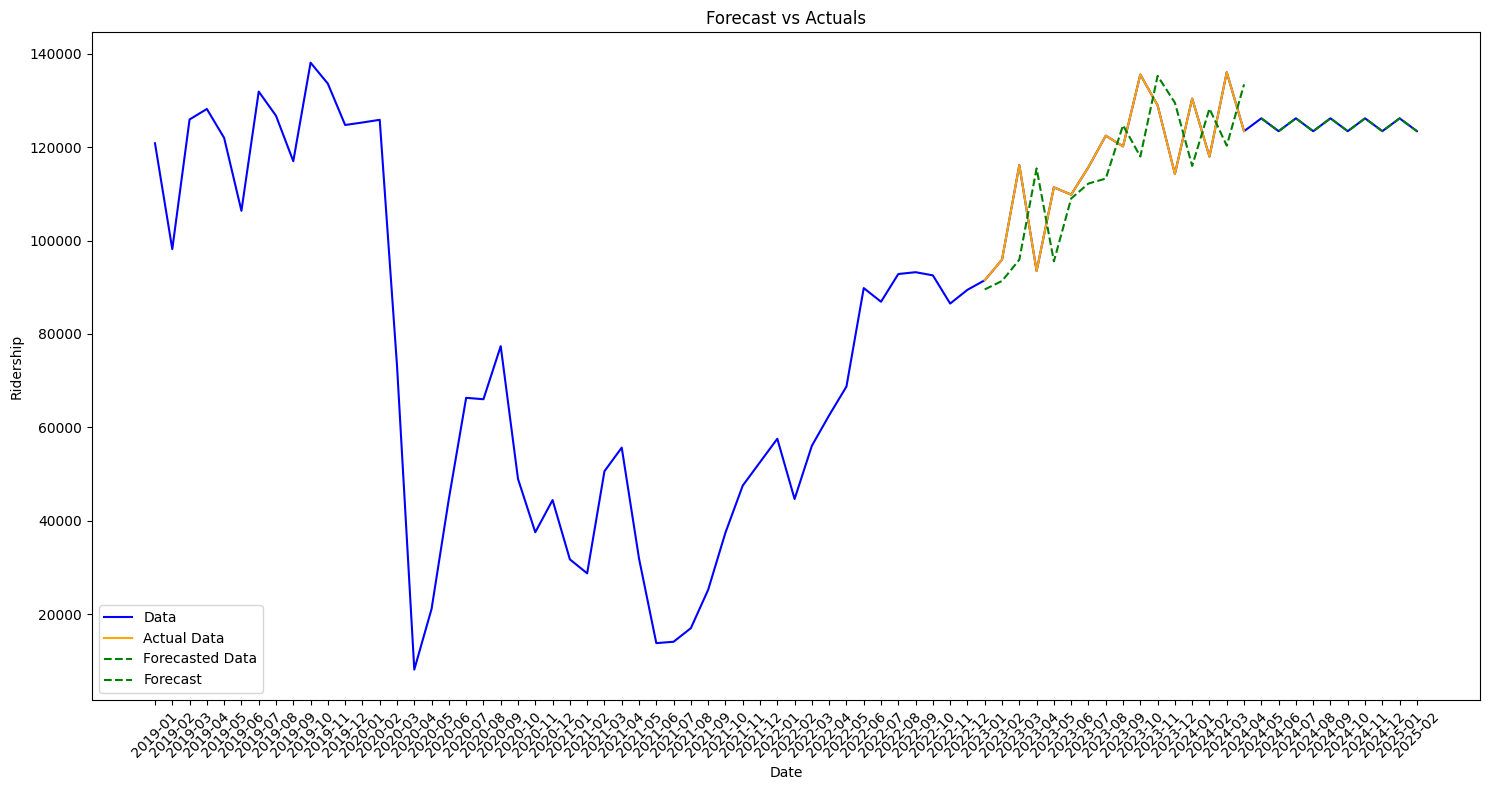

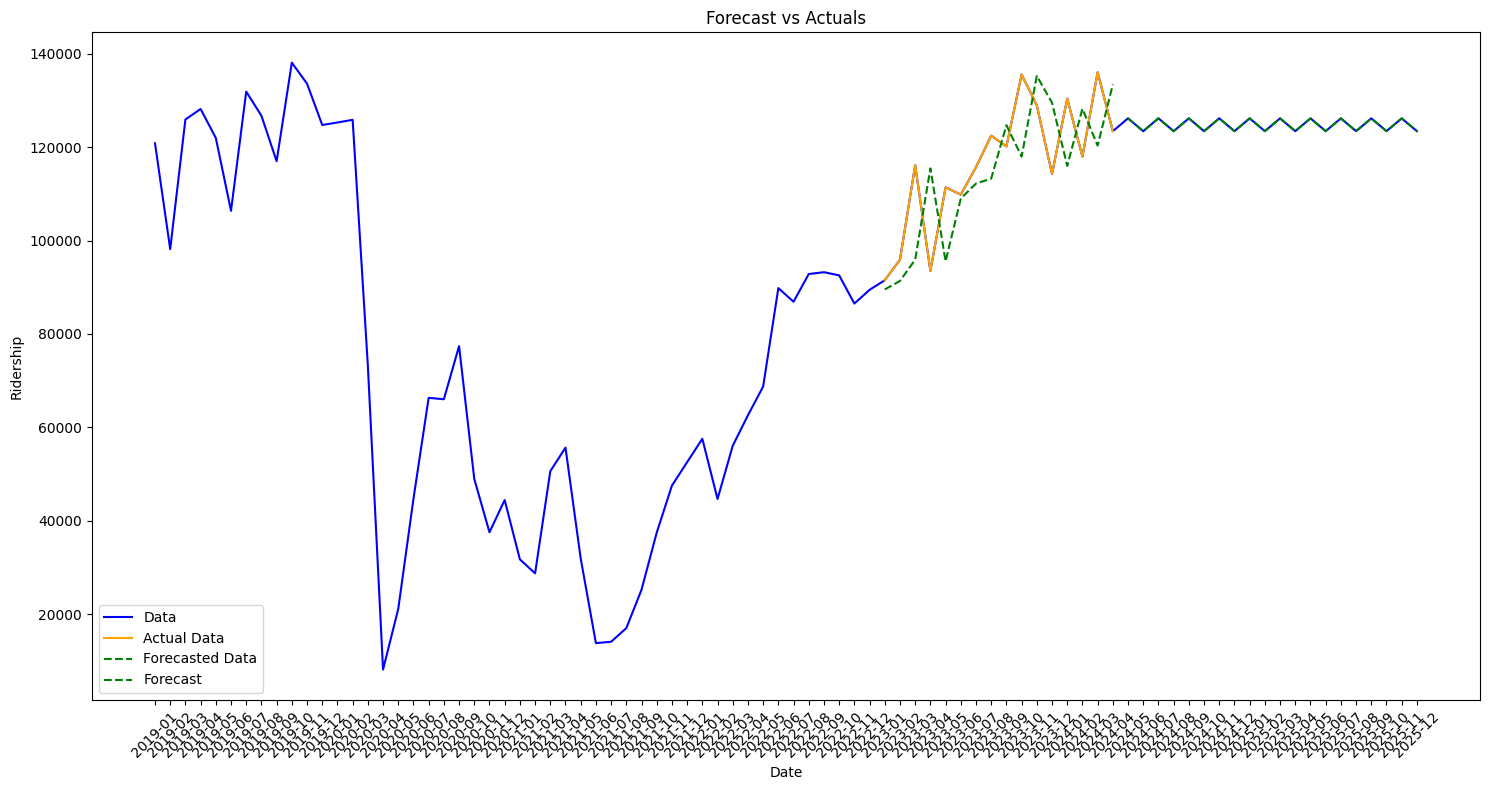

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_forecast(n_periods, results, filtered_df, future_dates):
    # Generate forecasts for the next n_periods points beyond the end of the testing set
    forecasts = results.forecast(steps=n_periods)
    future_index = pd.date_range(start=filtered_df.index[-1], periods=n_periods+1, freq='ME')[1:]  # Generate future dates
    b = np.array(forecasts)  # Convert forecasted testing data into array
    future_forecast1 = pd.DataFrame(b, index=future_index, columns=['forecast'])  # Use future dates as index

    # Combine actual and forecasted data for plotting
    combined_data = pd.concat([filtered_df['Ara Damansara'], future_forecast1['forecast']], axis=0)

    # Convert index to datetime objects and then to strings
    combined_data.index = pd.to_datetime(combined_data.index)
    combined_data.index = combined_data.index.strftime('%Y-%m')

    # Plotting
    plt.figure(figsize=(15, 8))
    plt.plot(combined_data.index, combined_data, label='Data', color='blue')
    plt.plot(result.index, result['Ara Damansara'], label='Actual Data', color='orange')
    plt.plot(result.index, result['forecast'], label='Forecasted Data', color='green', linestyle='--')
    plt.plot(future_forecast1.index.strftime('%Y-%m'), future_forecast1['forecast'], label='Forecast', color='green', linestyle='--')

    plt.title('Forecast vs Actuals')
    plt.xlabel('Date')
    plt.ylabel('Ridership')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

# Example usage:
# Define future dates
future_dates = pd.date_range(start=filtered_df.index[-1], periods=n_periods+1, freq='ME')[1:]

# Initial call to plot_forecast
plot_forecast(10, results, filtered_df, future_dates)  # Initial value of n_periods

# Now, whenever you change n_periods, you can call plot_forecast with the new value
plot_forecast(20, results, filtered_df, future_dates)  # For example, change n_periods to 30
